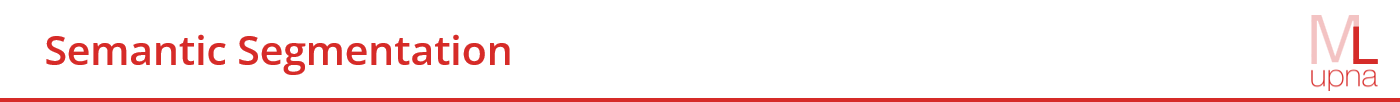

In this exercise, you will learn the fundamentals of <span style="color:#D52B29">semantic segmentation</span>, a core task in computer vision where the goal is to assign a <span style="color:#D52B29">class label</span> to each pixel of an image. Unlike classification, which predicts a single label for an entire image, or detection, which localizes objects with bounding boxes, semantic segmentation provides a much more detailed and structured understanding of visual content.

We will use the <span style="color:#D52B29">Clothing Co-Parsing (CCP)</span> dataset, which contains images of people annotated with pixel-level labels for different clothing categories. To simplify the problem and illustrate the task of segmentation, we will reduce the dataset into a <span style="color:#D52B29">binary problem</span> with only two classes: <span style="color:#D52B29">person</span> / <span style="color:#D52B29">background</span>.

![CCP Dataset](https://raw.githubusercontent.com/bearpaw/clothing-co-parsing/master/example.jpg)

Throughout the notebook, you will explore different approaches to segmentation:

- <span style="color:#D52B29">Sliding window</span> classification of the central pixel.

- <span style="color:#D52B29">Fully convolutional networks (FCNs)</span>.

- The <span style="color:#D52B29">U-Net</span> encoder-decoder architecture.

By the end of this practice, you will understand both the limitations of early approaches and the advantages of modern architectures in semantic segmentation.

## <span style="color:#D52B29">Sliding Window</span>

One of the earliest strategies for <span style="color:#D52B29">semantic segmentation</span> is the <span style="color:#D52B29">sliding window approach</span>. In this method, a fixed-size window is moved across the image, and a classifier predicts the <span style="color:#D52B29">label of the central pixel</span> based on the content inside the window.

While simple to implement, this approach, as we will see in this section, has several drawbacks:

- It is <span style="color:#D52B29">computationally expensive</span> since the network runs on many overlapping patches.

- The model often struggles to capture <span style="color:#D52B29">global context</span> because predictions are based only on local neighborhoods.

Despite these limitations, the sliding window method provides an intuitive first step toward understanding pixel-level classification.

In [1]:
# # Download from Huggingface
# !wget -q --show-progress https://huggingface.co/datasets/cayala/CCP/resolve/main/clothes.zip

# # Extract to folder
# !unzip -q clothes.zip

# # Remove the zip file
# !rm clothes.zip

In [2]:
# Buid dataset from folder structure

from glob import glob
import pandas as pd

images = glob('./clothes/*/images/*')
df = pd.DataFrame(images, columns=['image_path'])
df['mask_path'] = df.image_path.apply(lambda x : x.replace('/images/', '/labels/').replace('.jpg', '.png'))
df['set'] = df.image_path.apply(lambda x : x.split('/')[2])
df.head()

,image_path,mask_path,set
0,./clothes/test/images/0851.jpg,./clothes/test/labels/0851.png,test
1,./clothes/test/images/0852.jpg,./clothes/test/labels/0852.png,test
2,./clothes/test/images/0853.jpg,./clothes/test/labels/0853.png,test
3,./clothes/test/images/0854.jpg,./clothes/test/labels/0854.png,test
4,./clothes/test/images/0855.jpg,./clothes/test/labels/0855.png,test


In [3]:
import pandas as pd

classes = pd.read_csv("clothes/class_dict.csv")

print(classes)

     class_name    r    g    b
0           NaN   69    6   90
1   accessories   70   12   95
2           bag   71   18  101
3          belt   72   25  107
4        blazer   72   30  112
5        blouse   72   35  116
6      bodysuit   71   40  120
7         boots   70   47  124
8           bra   69   52  127
9      bracelet   68   57  130
10         cape   66   61  132
11     cardigan   64   67  135
12        clogs   62   72  136
13         coat   61   76  137
14        dress   58   82  139
15     earrings   56   86  139
16        flats   54   90  140
17      glasses   52   94  141
18       gloves   50   99  141
19         hair   48  103  141
20          hat   46  107  142
21        heels   45  111  142
22       hoodie   43  116  142
23     intimate   41  120  142
24       jacket   40  123  142
25        jeans   38  127  142
26       jumper   36  132  141
27     leggings   35  136  141
28      loafers   34  139  141
29     necklace   32  144  140
30      panties   31  148  139
31      

In [4]:
# import pandas as pd
# import io

# # Load your data
# # (Assuming 'classes' is already loaded as your DataFrame)
# # For example: classes = pd.read_csv("clothes/class_dict.csv")

# # 1. Standard One-Hot Encoding
# # This converts 'class_name' into multiple binary columns (0 or 1).
# # By default, this ignores the 'NaN' value in the first row (row 0 will be all zeros for class columns).
# encoded_classes = pd.get_dummies(classes, columns=['class_name'])

# # 2. Include NaN as a category (Optional)
# # If you want 'NaN' to have its own column (class_name_nan), set dummy_na=True.
# encoded_classes_with_na = pd.get_dummies(classes, columns=['class_name'], dummy_na=True)

# # View the results
# print(encoded_classes.head())

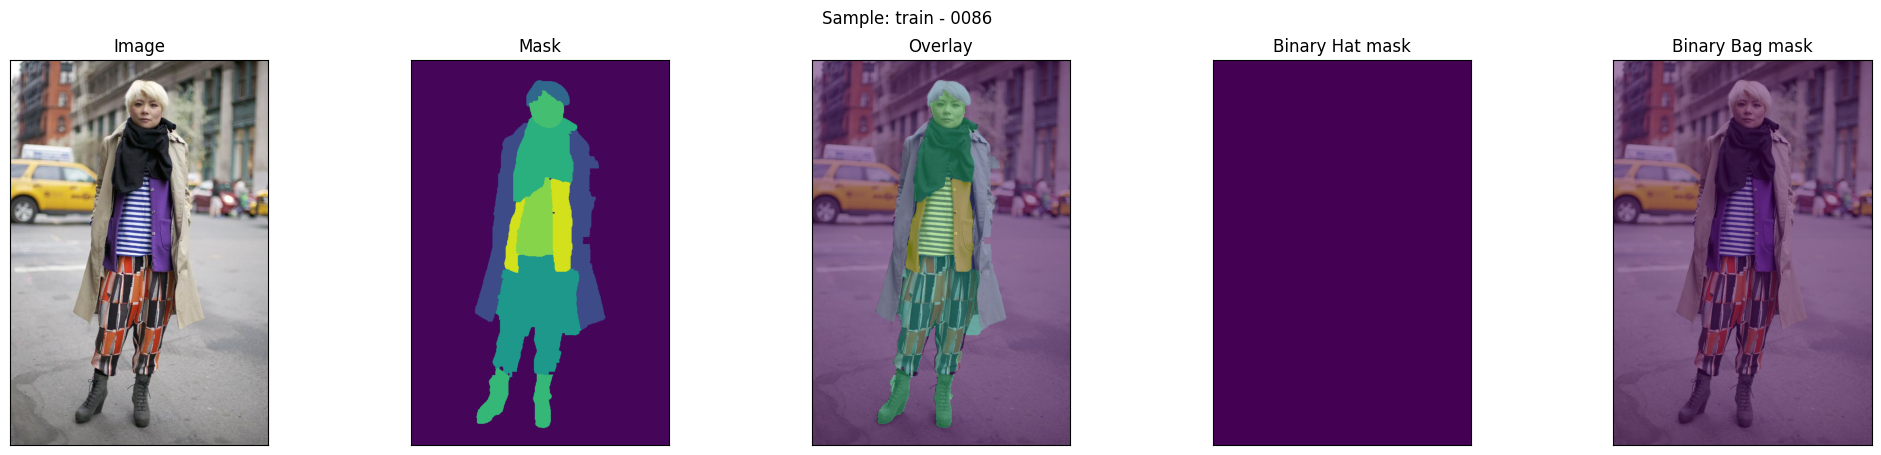

In [5]:
# Inspect a randomly taken sample
import matplotlib.pyplot as plt
from skimage.io import imread
import os
import numpy as np

r = df.sample(1).iloc[0]

x = imread(r.image_path)
y = imread(r.mask_path)


f, ax = plt.subplots(1, 5, figsize=(25, 5))

f.suptitle(f'Sample: {r.set} - {os.path.basename(r.image_path).split(".")[0]} ')

ax[0].imshow(x)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Image')

ax[1].imshow(y)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('Mask')

ax[2].imshow(x)
ax[2].imshow(y, alpha=.5)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title('Overlay')

hat_mask = (y != np.array([46, 107, 142])).any(-1) # [69,  6, 90] RGB values = background
ax[3].imshow(hat_mask)
ax[3].set_xticks([])
ax[3].set_yticks([])
ax[3].set_title('Binary Hat mask')




bag_mask = (y != np.array([71, 18, 101])).any(-1)
    
ax[4].imshow(x)
ax[4].imshow(bag_mask, alpha=.5)
ax[4].set_xticks([])
ax[4].set_yticks([])
ax[4].set_title('Binary Bag mask')

plt.show()

We start by creating a function that extracts a <span style="color:#D52B29">random patch</span> from an image and assigns it the class corresponding to the <span style="color:#D52B29">central pixel</span> of the patch. It is important to note that, for model training, we will select <span style="color:#D52B29">random patches</span> from the images, since extracting all possible patches corresponding to every pixel in the training images would be <span style="color:#D52B29">computationally infeasible</span>.

In [6]:
def random_crop(img, mask, patch_size=224):
    """
    Take a random [patch_size, patch_size, :] window from an image [H, W, :] and corresponding mask [H, W, :].
    
    Args:
        img: numpy array of shape [H, W, :]
        mask: numpy array of shape [H, W, :]
        patch_size: patch size (int)
    
    Returns:
        img_patch: numpy array of shape [patch_size, patch_size, 3]
        mask_patch: numpy array of shape [patch_size, patch_size, 3]
    """
    H, W, _ = img.shape
        
    # Random top-left corner
    y = np.random.randint(0, H - patch_size + 1)
    x = np.random.randint(0, W - patch_size + 1)
    
    # Extract patch
    img_patch = img[y:y+patch_size, x:x+patch_size, :]
    mask_patch = mask[y:y+patch_size, x:x+patch_size, :]
    
    return img_patch, mask_patch

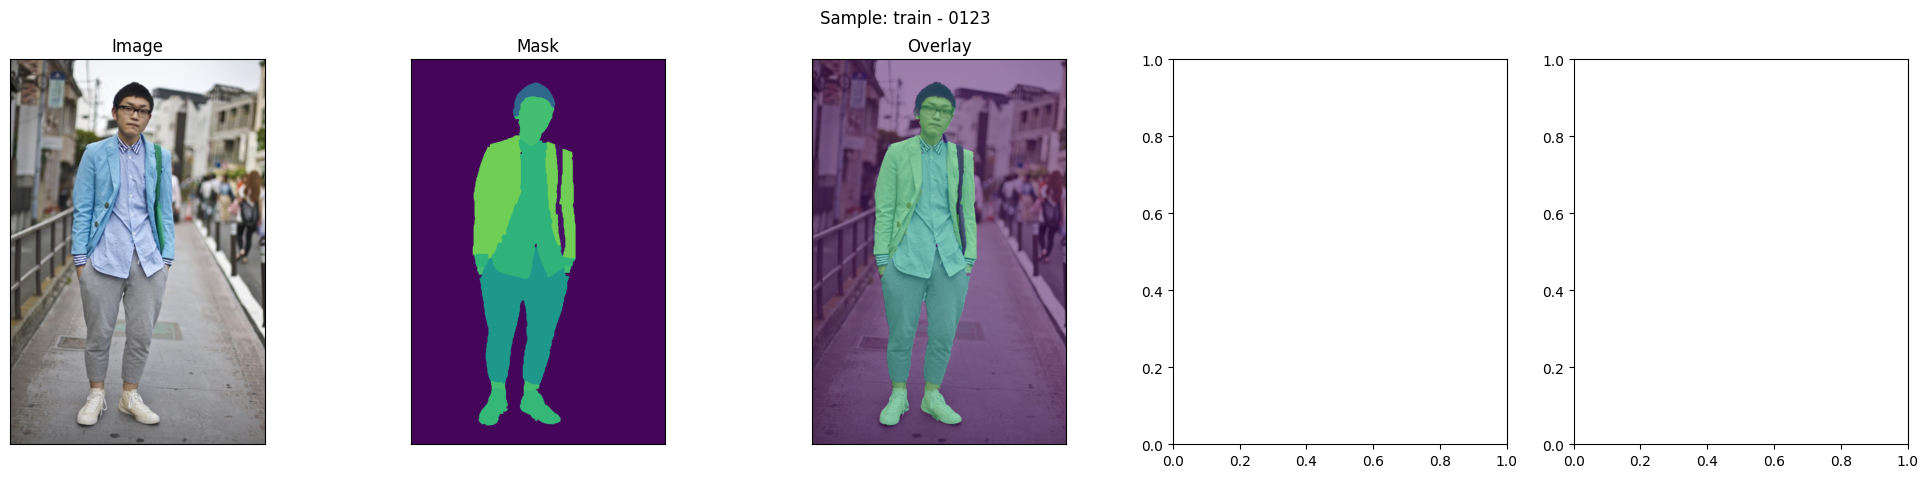

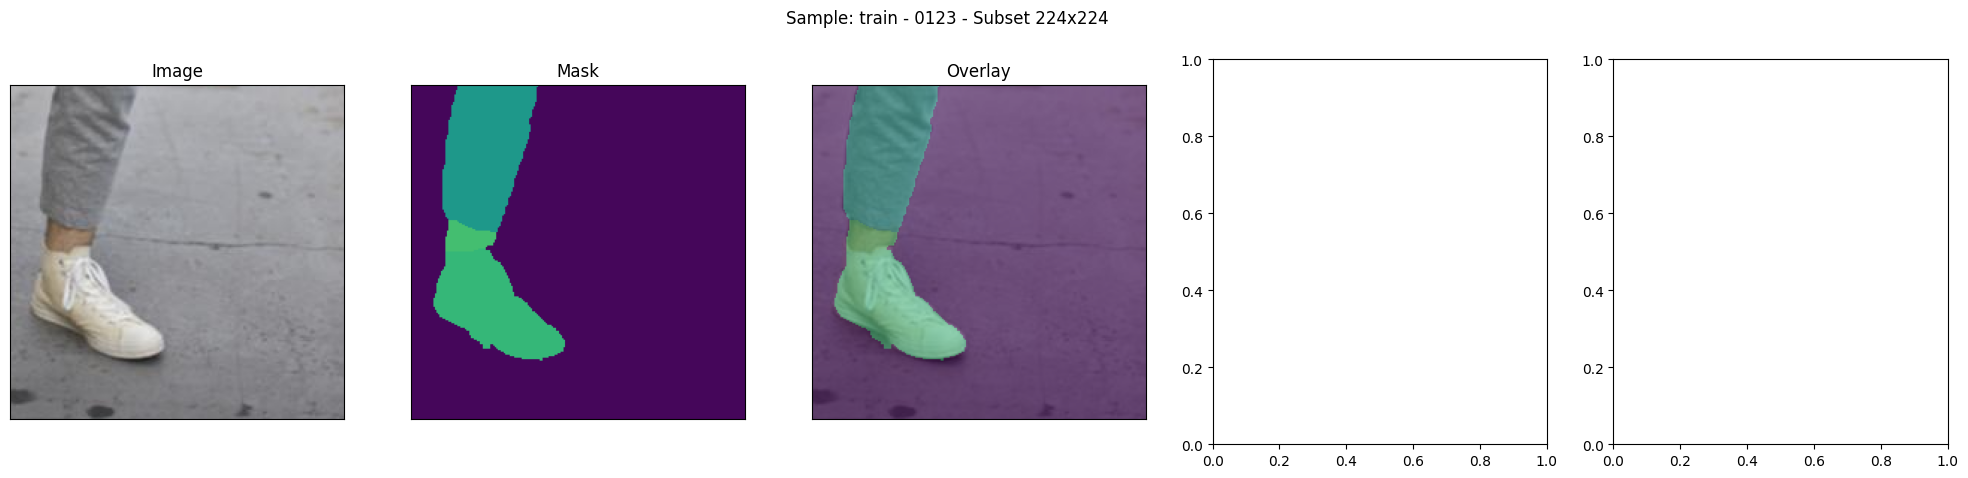

In [7]:
# Inspect a randomly taken sample
import matplotlib.pyplot as plt
from skimage.io import imread
import os
import numpy as np

r = df.sample(1).iloc[0]

x = imread(r.image_path)
y = imread(r.mask_path)

f, ax = plt.subplots(1, 5, figsize=(25, 5))

f.suptitle(f'Sample: {r.set} - {os.path.basename(r.image_path).split(".")[0]} ')

ax[0].imshow(x)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Image')

ax[1].imshow(y)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('Mask')

ax[2].imshow(x)
ax[2].imshow(y, alpha=.5)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title('Overlay')

# binary_mask = (y != np.array([69,  6, 90])).any(-1) # [69,  6, 90] RGB values = background
# ax[3].imshow(binary_mask)
# ax[3].set_xticks([])
# ax[3].set_yticks([])
# ax[3].set_title('Binary Mask')

# ax[4].imshow(x)
# ax[4].imshow(binary_mask, alpha=.5)
# ax[4].set_xticks([])
# ax[4].set_yticks([])
# ax[4].set_title('Overlay')

plt.show()

# Subset

img_patch, mask_patch = random_crop(x, y, patch_size=224)

f, ax = plt.subplots(1, 5, figsize=(25, 5))

f.suptitle(f'Sample: {r.set} - {os.path.basename(r.image_path).split(".")[0]} - Subset 224x224')

ax[0].imshow(img_patch)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Image')

ax[1].imshow(mask_patch)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('Mask')

ax[2].imshow(img_patch)
ax[2].imshow(mask_patch, alpha=.5)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title('Overlay')

# binary_mask_patch = (mask_patch != np.array([69,  6, 90])).any(-1) # [69,  6, 90] RGB values = background
# ax[3].imshow(binary_mask_patch)
# ax[3].set_xticks([])
# ax[3].set_yticks([])
# ax[3].set_title('Binary Mask')

# ax[4].imshow(img_patch)
# ax[4].imshow(binary_mask_patch, alpha=.5)
# ax[4].set_xticks([])
# ax[4].set_yticks([])
# ax[4].set_title('Overlay')

plt.show()

In [8]:
mask_patch.shape

(224, 224, 3)

What we will do next is create a <span style="color:#D52B29">PyTorch Dataset</span> that takes as input a <span style="color:#D52B29">DataFrame</span> where each row corresponds to one example of the dataset. The <span style="color:#D52B29">getitem()</span> function will load the example at index <span style="color:#D52B29">idx</span>. That is, it will read the image and its corresponding mask, extract a <span style="color:#D52B29">random patch of size 224×224</span>, and then apply transformations to the input image, such as <span style="color:#D52B29">normalization using ImageNet statistics</span>.

In [9]:
import torch

In [10]:
from torchvision.transforms import v2

In [11]:
from torchvision.models import ResNet18_Weights

In [12]:
weights = ResNet18_Weights.IMAGENET1K_V1
transforms = weights.transforms()
# ds = CCPDataset(df, patch_size=224, transforms=transforms)

In [13]:
# rndm_idx = torch.randint(ds.__len__(), [1]).item()
# x, y = ds.__getitem__(rndm_idx)
# ds.__show_item__(x, y)

Once we have the <span style="color:#D52B29">Dataset</span>, we can create the <span style="color:#D52B29">DataLoaders</span> using the <span style="color:#D52B29">DataModule</span> class.

In [14]:
# --- IMPORTS ---
import lightning.pytorch as pl
import torch
import numpy as np
from skimage.io import imread
from torch.utils.data import DataLoader
import torchvision.transforms.v2 as T
from torchvision import tv_tensors  # <--- CRITICAL FOR MASKS

# --- DATASET ---
class CCPDataset(torch.utils.data.Dataset):

    def __init__(self, df, class_df=None, patch_size=224, transforms=None, mode='train'):
        super(CCPDataset, self).__init__()
        self.df = df
        self.ps = patch_size
        self.transforms = transforms
        self.mode = mode
        
        # 1. Multiclass LUT Setup
        if class_df is not None:
            self.color_to_class = np.zeros((256, 256, 256), dtype=np.int64)
            self.color_to_class.fill(0) 
            for index, row in class_df.iterrows():
                r, g, b = int(row['r']), int(row['g']), int(row['b'])
                self.color_to_class[r, g, b] = index
        else:
            self.color_to_class = None

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # 1. Read Images
        x = imread(row.image_path)
        y = imread(row.mask_path)

        # 2. Handle Grayscale/RGBA -> RGB
        if x.ndim == 2: x = np.stack([x]*3, axis=-1)
        elif x.ndim == 3 and x.shape[2] == 4: x = x[:, :, :3]
        if y.ndim == 3 and y.shape[2] == 4: y = y[:, :, :3]

        # 3. Handle Eval Mode (Deterministic Crop)
        if self.mode == 'eval':
            r_start, c_start = row.coords
            x = x[r_start:r_start+self.ps, c_start:c_start+self.ps]
            y = y[r_start:r_start+self.ps, c_start:c_start+self.ps]
        
        # 4. Color Mapping (RGB -> Class Index)
        y_indices = self.color_to_class[y[:, :, 0], y[:, :, 1], y[:, :, 2]]

        # 5. Prepare Tensors (Wrap in tv_tensors to ensure v2 works correctly)
        x = torch.from_numpy(x).permute(2, 0, 1) # (C, H, W)
        y = torch.from_numpy(y_indices)          # (H, W)
        
        # WRAP: This tells v2 that 'y' is a Mask (use Nearest Neighbor resize)
        # and 'x' is an Image.
        x = tv_tensors.Image(x)
        y = tv_tensors.Mask(y)

        # 6. Apply Transforms
        if self.transforms:
            if isinstance(self.transforms, (tuple, list)) and len(self.transforms) == 2:
                t_joint, t_img = self.transforms
                
                if self.mode == 'train':
                    # JOINT: RandomCrop + Resize
                    # Because y is wrapped in tv_tensors.Mask, Resize works correctly!
                    x, y = t_joint(x, y) 
                    
                    # IMAGE ONLY: Normalize
                    x = t_img(x)
                else:
                    # EVAL: Just Normalize (we cropped manually above)
                    x = t_img(x)
            else:
                x = self.transforms(x)

        # 7. Final Output
        # y is likely still tv_tensors.Mask, convert to pure LongTensor
        y = y.data.long().unsqueeze(0) # (1, H, W)

        return x, y.squeeze(0) # (H, W)

    def __len__(self): 
        return self.df.shape[0]

# --- DATAMODULE (Re-define to use new CCPDataset) ---
class DataModule(pl.LightningDataModule):
    def __init__(self, df, classes, bs=64, ps=224):
        super().__init__()
        self.df = df
        self.classes = classes
        self.bs = bs
        self.ps = ps

    def patch_origins(self, h, w, ps, overlap=.5):
        if ps > h or ps > w: raise ValueError("Patch too big")
        stride = int(ps * overlap)
        if stride <= 0: raise ValueError("Stride too small")
        hs = list(range(0, h - ps + 1, stride))
        ws = list(range(0, w - ps + 1, stride))
        if hs[-1] != h - ps: hs.append(h - ps)
        if ws[-1] != w - ps: ws.append(w - ps)
        return np.array([(h, w) for h in hs for w in ws], dtype=int)

    def setup(self, stage=None): 
        # Defines transforms
        train_transforms = (
            T.Compose([
                T.RandomCrop((self.ps, self.ps)), 
                T.Resize(size=(224, 224), antialias=True), 
            ]),
            T.Compose([
                T.ToImage(), 
                T.ToDtype(torch.float32, scale=True),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ])
        )

        eval_transforms = (
            T.Compose([ T.Resize(size=(224, 224), antialias=True) ]),
            T.Compose([
                T.ToImage(), 
                T.ToDtype(torch.float32, scale=True),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ])
        )
        
        # Instantiate Datasets
        self.train_ds = CCPDataset(
            df=self.df.query('set == "train"'), 
            class_df=self.classes,    
            patch_size=self.ps, 
            transforms=train_transforms,
            mode='train'
        )

        # Build Validation with Patches
        valid_df = self.df.query('set == "valid"').copy()
        valid_df['coords'] = valid_df.image_path.apply(
            lambda x : self.patch_origins(*imread(x).shape[:-1], ps=self.ps, overlap=1).tolist()
        )
        valid_df = valid_df.explode('coords')

        self.valid_ds = CCPDataset(
            df=valid_df, 
            class_df=self.classes,
            patch_size=self.ps, 
            transforms=eval_transforms, 
            mode='eval'
        )
        
        # Build Test with Patches
        test_df = self.df.query('set == "test"').copy()
        test_df['coords'] = test_df.image_path.apply(
            lambda x : self.patch_origins(*imread(x).shape[:-1], ps=self.ps, overlap=1).tolist()
        )
        test_df = test_df.explode('coords')

        self.test_ds = CCPDataset(
            df=test_df, 
            class_df=self.classes,
            patch_size=self.ps, 
            transforms=eval_transforms, 
            mode='eval'
        )

    def train_dataloader(self): 
        return DataLoader(self.train_ds, batch_size=self.bs, shuffle=True, num_workers=2)

    def val_dataloader(self): 
        return DataLoader(self.valid_ds, batch_size=self.bs, shuffle=False, num_workers=2)

    def test_dataloader(self): 
        return DataLoader(self.test_ds, batch_size=self.bs, shuffle=False, num_workers=2)

# --- EXECUTION ---
# 1. Re-instantiate DataModule (This clears the old class logic)
data_module = DataModule(df, classes, bs=64, ps=224)
data_module.setup('train')

# 2. Test
print("Testing Batch Generation...")
batch = next(iter(data_module.train_dataloader()))
print(f"Success! Batch X: {batch[0].shape}, Batch Y: {batch[1].shape}")

Testing Batch Generation...
Success! Batch X: torch.Size([64, 3, 224, 224]), Batch Y: torch.Size([64, 224, 224])


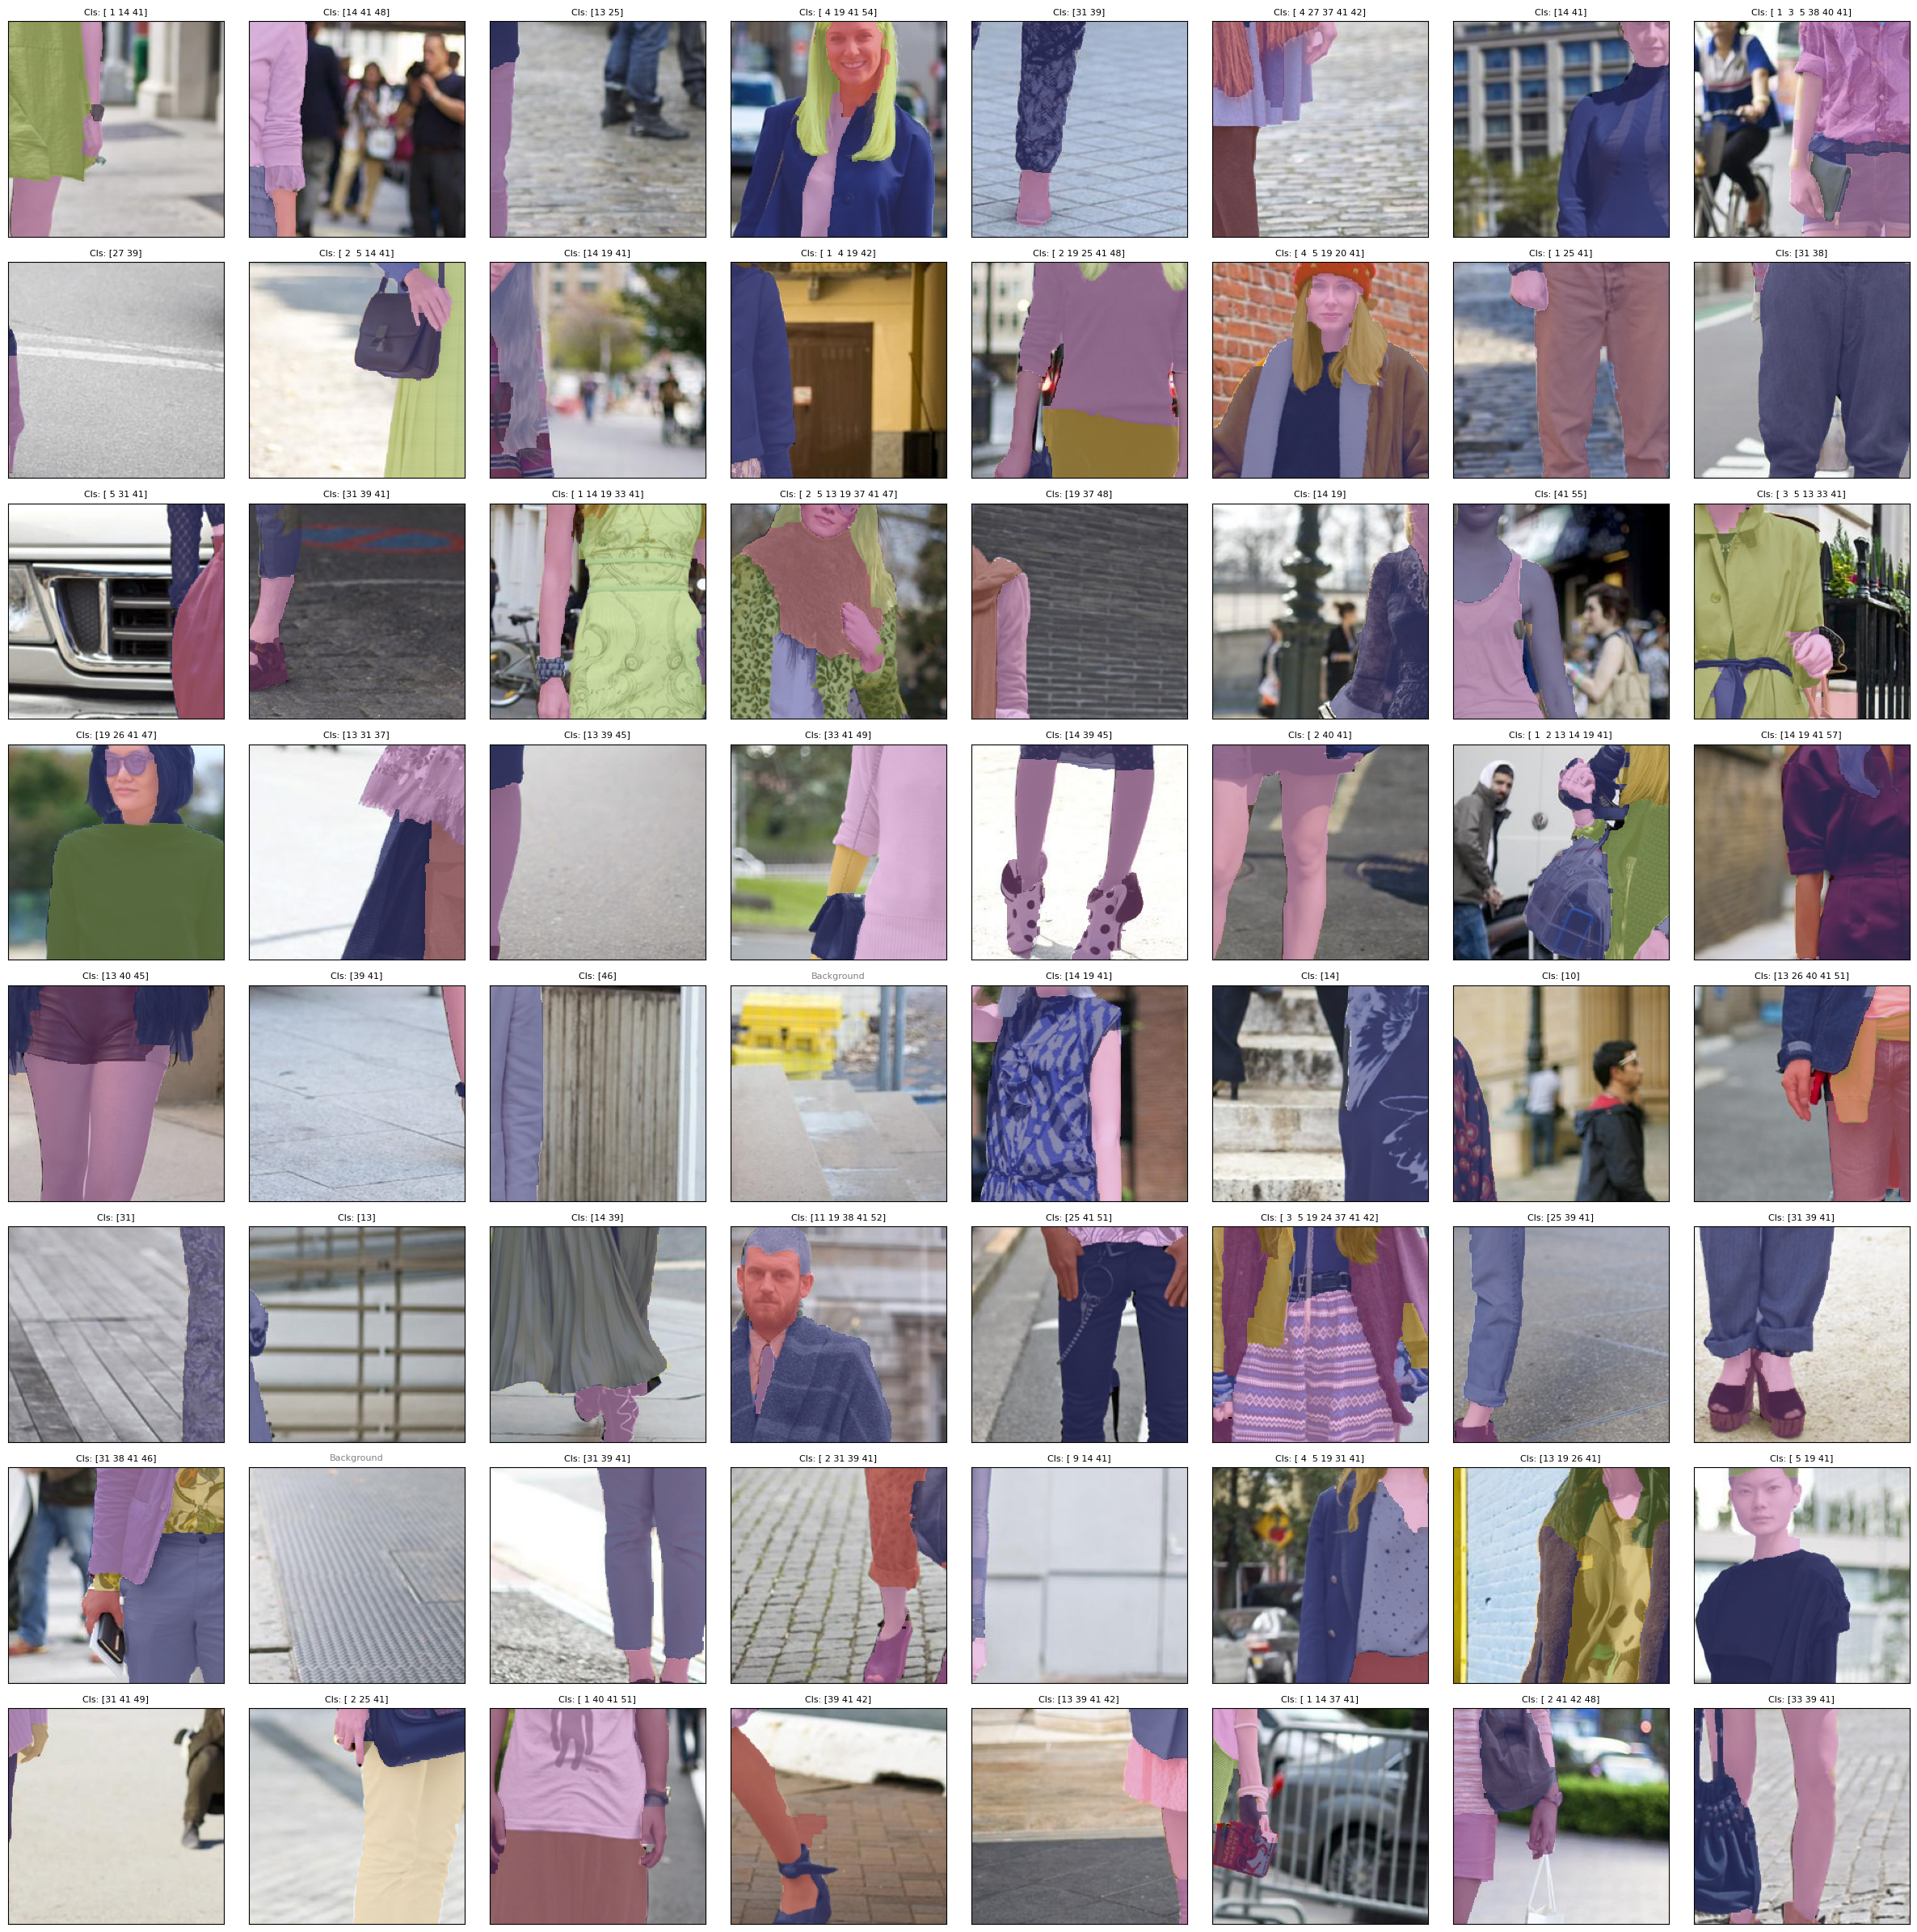

In [15]:
import matplotlib.pyplot as plt

# Define Un-Normalization (Reverse ImageNet stats)
# x_new = x * std + mean
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denormalize(img_tensor):
    return (img_tensor * std + mean).clamp(0, 1)

# Get a batch
batch = next(iter(data_module.train_dataloader()))
images, masks = batch

# Setup plot
f, ax = plt.subplots(8, 8, figsize=(24, 24))
ax = ax.ravel()

for i in range(64):
    # 1. Denormalize image for display
    img_vis = denormalize(images[i]).permute(1, 2, 0).numpy()
    
    # 2. Get the mask (Integers 0-58)
    mask_vis = masks[i].numpy()
    
    # 3. Plot Image
    ax[i].imshow(img_vis)
    
    # 4. Overlay Mask (with transparency)
    # We filter out class 0 (background) so the image is visible
    masked_data = np.ma.masked_where(mask_vis == 0, mask_vis)
    ax[i].imshow(masked_data, cmap='tab20b', alpha=0.6, interpolation='nearest')
    
    # Clean up axes
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    
    # Optional: Title shows unique classes found in this patch
    unique_classes = np.unique(mask_vis)
    unique_classes = unique_classes[unique_classes != 0] # Remove background
    if len(unique_classes) > 0:
        ax[i].set_title(f"Cls: {unique_classes}", fontsize=8)
    else:
        ax[i].set_title("Background", fontsize=8, color='gray')

plt.tight_layout()
plt.show()

## <span style="color:#D52B29">Encoder-Decoder Architecture</span>

In previous sections, we saw that convolutional networks used for classification extract information from the original image at multiple levels. Each level compresses information more, producing richer features. However, in the first strategy (sliding window), this does not help for segmentation since we would need to classify pixel by pixel.

The second strategy we explored does not compress the information and works at the original resolution, allowing segmentation in a single pass. Unfortunately, it is also not ideal due to the high computational cost.

The solution is to <span style="color:#D52B29">combine both approaches</span>. We will use <span style="color:#D52B29">FCNNs that internally compress and decompress information</span>. Pooling layers reduce dimensionality (<span style="color:#D52B29">encoder</span>), while deconvolution or upsampling layers restore it (<span style="color:#D52B29">decoder</span>). Additionally, most architectures include <span style="color:#D52B29">skip-connections</span> that transfer information from the encoder to the decoder for more precise reconstruction.

Among encoder-decoder architectures, there are many variations. Fastai focuses on the most widely used one due to its strong generalization across tasks: the <span style="color:#D52B29">U-Net</span>, named after the "U" shape of its structure, as illustrated below.

![Arquitectura Unet](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/u-net-architecture.png)

Imagen from: [U-Net: Convolutional Networks for Biomedical Image Segmentation
](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/#:~:text=The%20u%2Dnet%20is%20convolutional,and%20precise%20segmentation%20of%20images.&text=U%2Dnet%20architecture%20(example%20for,on%20top%20of%20the%20box.).

As we can see, the architecture starts with a CNN-like <span style="color:#D52B29">encoder</span>, consisting of convolutional and pooling layers. This part can be replaced with any CNN we’ve seen before (e.g., <span style="color:#D52B29">ResNet</span>), also called the <span style="color:#D52B29">backbone</span>. After compression, the <span style="color:#D52B29">decoder</span> uses upsampling and convolutional layers to restore spatial resolution. The horizontal arrows are <span style="color:#D52B29">skip-connections</span>, which pass features from each encoder level to the corresponding decoder layer, improving spatial accuracy.

Although there are technical complexities like undoing pooling (<span style="color:#D52B29">upsampling</span>) or implementing deconvolutions, these details are abstracted when using Fastai’s <span style="color:#D52B29">U-Net</span> implementation, so we will focus on its practical use rather than the low-level operations.

To implement the <span style="color:#D52B29">U-Net</span> and other more advanced semantic segmentation architectures, we will use the <span style="color:#D52B29">Segmentation Models PyTorch</span> library. This library allows us to easily choose different encoders and configure various internal parameters of the network.

Next, we will see how to instantiate a <span style="color:#D52B29">U-Net</span> that uses a <span style="color:#D52B29">ResNet18 encoder</span> pre-trained on ImageNet.

In [16]:
!uv pip install segmentation_models_pytorch

Using Python 3.13.7 environment at: /home/alumno/py313ml/.venv
Audited 1 package in 105ms


In [17]:
import segmentation_models_pytorch as smp

In [18]:
n_classes = len(classes)

In [19]:
model = smp.Unet(
    encoder_name='resnet18',
    encoder_weights='imagenet',
    in_channels=3,
    classes=n_classes
)

model

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [20]:
x = torch.rand(1, 3, 256, 256)
y_hat = model(x)
y_hat.shape

torch.Size([1, 59, 256, 256])

We are now going to modify the <span style="color:#D52B29">LightningModule</span> to make use of this new <span style="color:#D52B29">U-Net model</span> and train it with the same parametrization as in the previous experiments, ensuring a <span style="color:#D52B29">fair comparison</span>.

In [21]:
import lightning.pytorch as pl
import torch
import torch.nn.functional as F
import segmentation_models_pytorch as smp

# 1. RENAME the class to avoid conflict with pl.LightningModule
class CCP_SegmentationModel(pl.LightningModule):
    
    # 2. Add n_classes as an argument so it's not a missing global variable
    def __init__(self, n_classes=59):
        super().__init__()
        self.save_hyperparameters()
        
        # Creating model
        self.model = smp.Unet(
            encoder_name='resnet18',
            encoder_weights='imagenet',
            in_channels=3,
            classes=n_classes
        )

        self.loss_fn = smp.losses.DiceLoss(mode='multiclass', from_logits=True)

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        # optimization
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        return {"optimizer": optimizer}

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        
        # 3. Shape Safety Check
        # If your Dataset returns (H, W), y is (Batch, H, W). No squeeze needed.
        # If your Dataset returns (1, H, W), y is (Batch, 1, H, W). Squeeze needed.
        if y.ndim == 4: 
            y = y.squeeze(1)
            
        # loss = F.cross_entropy(logits, y)
        loss = self.loss_fn(logits, y)
        # loss = smp.losses.DiceLoss(mode='multiclass', from_logits=True)
        
        # 4. Automatic Logging
        # 'prog_bar=True' shows the loss in the loading bar while training
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        
        if y.ndim == 4: 
            y = y.squeeze(1)

        # loss = F.cross_entropy(logits, y)
        loss = self.loss_fn(logits, y)
        
        # Logs to the CSVLogger automatically
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        
        return loss

    # You can remove on_train_epoch_end and on_validation_epoch_end.
    # The 'prog_bar=True' above handles the printing for you!

import segmentation_models_pytorch as smp
import torch

# class CCP_SegmentationModel(pl.LightningModule):
#     def __init__(self, n_classes=59):
#         super().__init__()
#         self.save_hyperparameters()
        
#         # 1. Model
#         self.model = smp.Unet(
#             encoder_name='resnet18',
#             encoder_weights='imagenet',
#             in_channels=3,
#             classes=n_classes
#         )
        
#         # 2. LOSS FUNCTION: Focal Loss
#         # 'mode="multiclass"' handles the index inputs automatically.
#         # 'normalized=True' helps stabilize the gradient.
#         self.loss_fn = smp.losses.FocalLoss(mode='multiclass', normalized=True)

#     def forward(self, x):
#         return self.model(x)

#     def configure_optimizers(self):
#         # 3. LOWER LEARNING RATE
#         # Reduced from 1e-3 to 1e-4 to preserve pre-trained weights
#         optimizer = torch.optim.Adam(self.parameters(), lr=1e-4)
#         return optimizer

#     def training_step(self, batch, batch_idx):
#         x, y = batch
#         logits = self(x)
        
#         # Squeeze if necessary (Batch, 1, H, W) -> (Batch, H, W)
#         if y.ndim == 4: 
#             y = y.squeeze(1)
            
#         loss = self.loss_fn(logits, y)
        
#         self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
#         return loss

#     def validation_step(self, batch, batch_idx):
#         x, y = batch
#         logits = self(x)
#         if y.ndim == 4: 
#             y = y.squeeze(1)

#         loss = self.loss_fn(logits, y)
#         self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
#         return loss

In [22]:
from lightning.pytorch.loggers import CSVLogger
import os

# Set random seed for reproducibility
pl.seed_everything(seed=42, workers=True)

# Intantiate LightningModule
lightning_module = CCP_SegmentationModel()

# Define a CSV logger to store training/validation metrics in CSV format.
csv_logger = CSVLogger(save_dir=os.getcwd(), name="ccp_unet")

# Define a checkpoint callback:
# It will save the model with the lowest validation loss ("best_valid_loss.ckpt").
model_checkpoint_callback = pl.callbacks.model_checkpoint.ModelCheckpoint(
    monitor='val_loss',mode='min', filename='best_valid_loss', verbose=True, save_last=False)

# Create a PyTorch Lightning trainer
trainer = pl.Trainer(max_epochs=30, logger=csv_logger, callbacks=[model_checkpoint_callback])

# Load the data module
data_module = DataModule(df, classes, bs=64, ps=224)#, transforms=transforms)

torch.set_float32_matmul_precision('medium')

# Train the model with the trainer, passing the core LightningModule and data module.
trainer.fit(lightning_module, data_module)

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type     | Params | Mode 
---------------------------------------------
0 | model   | Unet     | 14.3 M | train
1 | loss_fn | DiceLoss | 0      | train
---------------------------------------------
14.3 M    Trainable params
0         Non-trainable params
14.3 M    Total params
57.346    Total estimated model params size (MB)
141       Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

/home/alumno/py313ml/.venv/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (11) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

...

Epoch 27, global step 308: 'val_loss' reached 0.24806 (best 0.24806), saving model to '/home/alumno/Desktop/datos/Computer Vision/ccp_unet/version_34/checkpoints/best_valid_loss.ckpt' as top 1


Validation: |                                             | 0/? [00:00<?, ?it/s]

Epoch 28, global step 319: 'val_loss' was not in top 1


Validation: |                                             | 0/? [00:00<?, ?it/s]

Epoch 29, global step 330: 'val_loss' reached 0.24508 (best 0.24508), saving model to '/home/alumno/Desktop/datos/Computer Vision/ccp_unet/version_34/checkpoints/best_valid_loss.ckpt' as top 1
`Trainer.fit` stopped: `max_epochs=30` reached.


   epoch  step  train_loss  val_loss
0      0    10    0.603116  0.322625
1      1    21    0.582888  0.311266
2      2    32    0.583169  0.303867
3      3    43    0.561054  0.294650
4      4    54    0.570970  0.291213


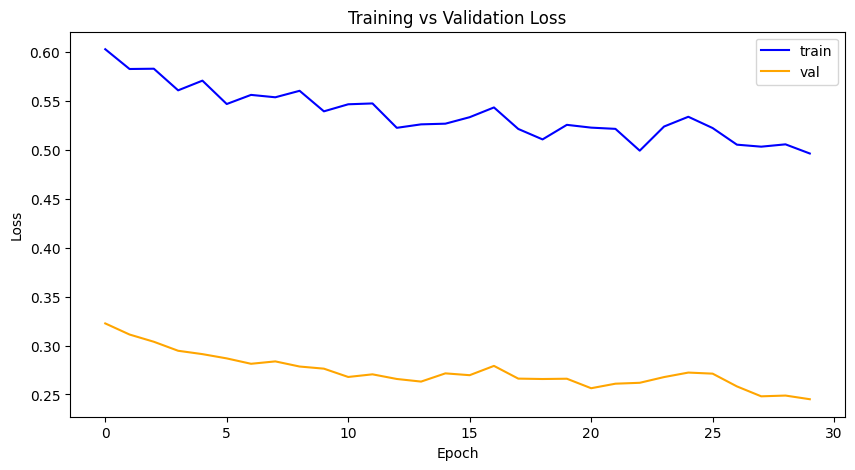

In [31]:
metric_df = pd.read_csv(f'{trainer.logger.log_dir}/metrics.csv')
metric_df = metric_df.groupby('epoch', as_index=False).first()
print(metric_df.head())

f, ax = plt.subplots(1, 1, figsize=(10, 5))
metric_df.train_loss.plot(ax=ax, color='blue', label='train')
metric_df.val_loss.plot(ax=ax, color='orange', label='val')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training vs Validation Loss')
ax.legend()
plt.show()

We will now load the best model and perform inference as before, in order to compute metrics and compare this approach with the previous ones.

In [36]:
# Get the path from the callback (verify it exists)
ckpt_path = model_checkpoint_callback.best_model_path
print(f"Loading model from: {ckpt_path}")

# LOAD CORRECTLY
# Do not pass 'model=model'. Pass the arguments your __init__ needs (n_classes).
best_model = CCP_SegmentationModel.load_from_checkpoint(
    checkpoint_path=ckpt_path,
    n_classes=n_classes
)

# Move to GPU and Eval
best_model.cuda()
best_model.eval()

# Update your inference loop to use 'best_model' instead of 'model'
logits = best_model(xi.cuda().unsqueeze(0))

Loading model from: /home/alumno/Desktop/datos/Computer Vision/ccp_unet/version_34/checkpoints/best_valid_loss.ckpt


In [25]:
# !uv pip install fastprogress

In [38]:
import torch
import numpy as np
import torchvision.transforms.v2 as T
from fastprogress import master_bar, progress_bar
from torch import nn
from skimage.io import imread
from sklearn.metrics import accuracy_score, jaccard_score, f1_score

# 1. SETUP COLOR MAPPING (Run this once)
# We need this to convert the Test Mask (RGB) into Truth Indices (0-58)
color_to_class = np.zeros((256, 256, 256), dtype=np.int64)
color_to_class.fill(0) # Default background
for index, row in classes.iterrows():
    r, g, b = int(row['r']), int(row['g']), int(row['b'])
    color_to_class[r, g, b] = index

# 2. SETUP TRANSFORMS
# Must match training: Tensor -> Float -> Normalize
ps = 224 # Patch size used in training
n_classes = 59 

inf_transforms = T.Compose([
    T.ToImage(), 
    T.ToDtype(torch.float32, scale=True), # Divides by 255
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Ensure model is in Eval mode and on GPU
best_model.eval()
best_model.cuda()

metric_dict = []
test_df = df.query('set == "test"')

mb = master_bar(test_df.iterrows(), total=test_df.shape[0])

for i, r in mb:

    # Read image and mask
    x = imread(r.image_path)
    y = imread(r.mask_path)
    
    # --- CHANGE 1: Convert RGB Mask to Index Mask ---
    # We use the LUT to get a (H, W) array of integers 0-58
    y_true = color_to_class[y[:, :, 0], y[:, :, 1], y[:, :, 2]]
    
    # Compute origins
    h, w = y_true.shape
    # Use the DataModule's static method or the logic you defined earlier
    coords = DataModule.patch_origins(None, h, w, ps=ps, overlap=1).tolist()

    # Initialize y_hat (Accumulator for probabilities)
    # Shape: (59, H, W)
    y_hat = torch.zeros((n_classes, h, w), dtype=torch.float32, device='cuda')
    y_wei = torch.zeros((1, h, w), dtype=torch.float32, device='cuda') 
    
    # Perform inference
    for (coord_x, coord_y) in progress_bar(coords, parent=mb):
            
        # Crop
        xi = x[coord_x:coord_x+ps, coord_y:coord_y+ps]
        
        # Apply transforms (Numpy -> Tensor normalized)
        # Result is (3, 224, 224)
        xi = inf_transforms(xi)

        # Forward
        with torch.no_grad():
            # Input: (1, 3, 224, 224) -> Output: (1, 59, 224, 224)
            logits = best_model(xi.unsqueeze(0).cuda())
            # Softmax over channel dim (1) -> (59, 224, 224)
            probs = nn.Softmax(dim=1)(logits)[0] 

        # Store predictions
        y_hat[:, coord_x:coord_x+ps, coord_y:coord_y+ps] += probs
        y_wei[:, coord_x:coord_x+ps, coord_y:coord_y+ps] += 1

    # Normalize accumulated probabilities
    y_hat /= y_wei
    
    # --- CHANGE 2: Argmax to get Final Class Indices ---
    # (59, H, W) -> (H, W) with integers 0-58
    y_hat_indices = y_hat.argmax(0).cpu().numpy()

    # --- CHANGE 3: Multiclass Metrics ---
    # We must flatten the arrays and use average='macro' (or 'weighted')
    # 'macro': Calculate metrics for each class, and find their unweighted mean. 
    # This treats all classes equally (socks are as important as background).
    
    metric_dict.append({
        'pixel_acc': accuracy_score(y_true.ravel(), y_hat_indices.ravel()),
        'iou': jaccard_score(y_true.ravel(), y_hat_indices.ravel(), average='macro', zero_division=0),
        'dice': f1_score(y_true.ravel(), y_hat_indices.ravel(), average='macro', zero_division=0)
    })

# View results
import pandas as pd
metrics_df = pd.DataFrame(metric_dict)
print(metrics_df.mean())

pixel_acc    0.814736
iou          0.123419
dice         0.147963
dtype: float64


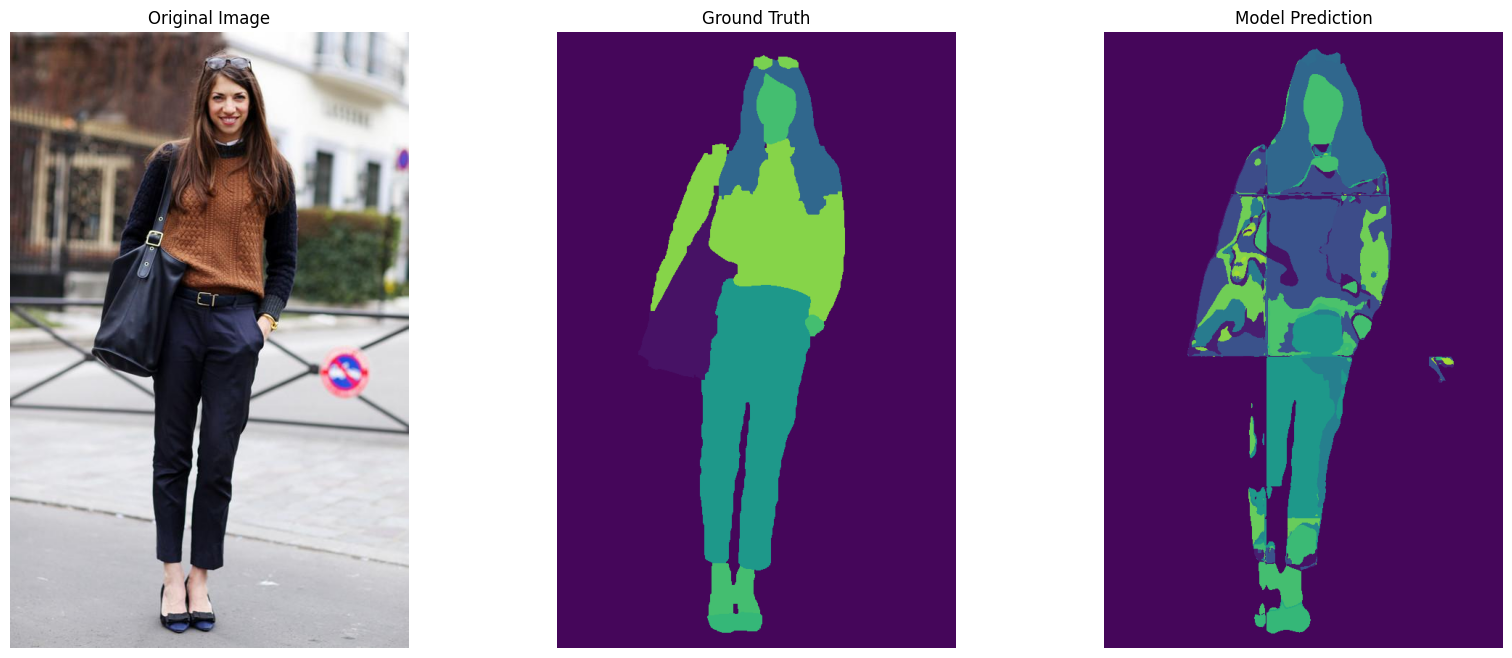

In [39]:
import matplotlib.pyplot as plt
import numpy as np

def decode_segmap(mask_indices, class_df):
    """
    Converts a mask of indices (H, W) into an RGB image (H, W, 3)
    using the colors from class_df.
    """
    h, w = mask_indices.shape
    rgb_mask = np.zeros((h, w, 3), dtype=np.uint8)
    
    # Loop only through the unique classes present in this mask (faster)
    for idx in np.unique(mask_indices):
        if 0 <= idx < len(class_df):
            # Extract color for this class ID
            color = class_df.iloc[idx][['r', 'g', 'b']].values
            rgb_mask[mask_indices == idx] = color
            
    return rgb_mask

# --- Visualization Loop (Copy paste this into your notebook) ---
# We will visualize the last processed image from your loop (or you can pick a specific one)

# 1. Decode the Ground Truth
rgb_true = decode_segmap(y_true, classes)

# 2. Decode the Prediction
rgb_pred = decode_segmap(y_hat_indices, classes)

# 3. Plot
fig, ax = plt.subplots(1, 3, figsize=(20, 8))

# Original Image
ax[0].imshow(x)
ax[0].set_title("Original Image")
ax[0].axis('off')

# Ground Truth
ax[1].imshow(rgb_true)
ax[1].set_title("Ground Truth")
ax[1].axis('off')

# Prediction
ax[2].imshow(rgb_pred)
ax[2].set_title("Model Prediction")
ax[2].axis('off')

plt.savefig("horrible_performance.png", dpi=400)
plt.show()

**CHECK WTF IS BEING LOADED**

In [40]:
# Instantiate your DataModule
dm = DataModule(df, classes, bs=16, ps=224)
dm.setup('fit')
train_loader = dm.train_dataloader()

# Get one batch
batch_x, batch_y = next(iter(train_loader))

print(f"Images Shape: {batch_x.shape}")
print(f"Masks Shape:  {batch_y.shape}")
print("--- Data Integrity Check ---")
print(f"Unique values in Target Mask (y): {torch.unique(batch_y)}")

# CRITICAL CHECK
if len(torch.unique(batch_y)) == 1:
    print("\n❌ FATAL ERROR: Your training masks are ALL ONE CLASS (likely 0).")
    print("The model cannot learn because the inputs are empty.")
    print("Check your 'color_to_class' mapping or your 'class_dict.csv'.")
else:
    print("\n✅ Data looks okay. Proceed to Diagnostic 2.")

Images Shape: torch.Size([16, 3, 224, 224])
Masks Shape:  torch.Size([16, 224, 224])
--- Data Integrity Check ---
Unique values in Target Mask (y): tensor([ 0,  1,  2,  3,  4,  9, 13, 14, 19, 22, 31, 33, 37, 38, 39, 40, 41, 46,
        48, 51, 55, 57])

✅ Data looks okay. Proceed to Diagnostic 2.


In [41]:
pd.DataFrame.from_records(metric_dict).mean(0)

pixel_acc    0.814736
iou          0.123419
dice         0.147963
dtype: float64

As we can see, the results obtained with <span style="color:#D52B29">U-Net</span> are the best so far. We not only gain in <span style="color:#D52B29">efficiency</span> but also in <span style="color:#D52B29">accuracy</span>. This strategy is therefore the one we should follow to tackle <span style="color:#D52B29">semantic segmentation</span> problems.

| Experiment      | Inference time    | Sample | Accuracy | IoU  | Dice |
|:---------------:|:----------------:|:------:|:--------:|:----:|:----:|
| Sliding Window  | 30m* / image     | 0851   | 83.89    | 0.56 | 0.71 |
| FCNN            | 1s / image       | 0851   | 79.76    | 0.34 | 0.51 |
| U-Net           | 1s / image       | 0851   | 94.98    | 0.81 | 0.89 |

*Inference time for the sliding window approach may be reduced applying batches.

There are, of course, other <span style="color:#D52B29">semantic segmentation</span> architectures besides U-Net (although most share the same <span style="color:#D52B29">encoder-decoder</span> principle). The <span style="color:#D52B29">segmentation models pytorch</span> library makes it easy to try out different configurations. I encourage you to experiment with them!

## <span style="color:#D52B29">Summary</span>

In this exercise, you have learned the fundamentals of <span style="color:#D52B29">semantic segmentation</span>, a key task in <span style="color:#D52B29">computer vision</span> where the goal is to assign a <span style="color:#D52B29">class label</span> to each pixel of an image. Unlike <span style="color:#D52B29">classification</span>, which predicts a single label for an entire image, or <span style="color:#D52B29">detection</span>, which localizes objects with bounding boxes, segmentation provides a much more detailed and structured understanding of visual content.

We have worked with the <span style="color:#D52B29">Clothing Co-Parsing (CCP)</span> dataset, simplified into a <span style="color:#D52B29">binary problem</span> with only two classes: <span style="color:#D52B29">person</span> / <span style="color:#D52B29">background</span>.

Throughout the notebook, you explored three different approaches to segmentation:

- <span style="color:#D52B29">Sliding window</span> classification of the central pixel.

- <span style="color:#D52B29">Fully convolutional networks (FCNs)</span>.

- The <span style="color:#D52B29">U-Net</span> encoder-decoder architecture.

You have seen how early methods, like the sliding window, can be conceptually simple but computationally inefficient. The FCN approach introduced a step forward, producing full-resolution masks in a single pass, but still suffered from accuracy issues. Finally, the U-Net architecture combined the strengths of both approaches by compressing and then reconstructing the information with the help of <span style="color:#D52B29">skip-connections</span>, leading to the best results both in terms of <span style="color:#D52B29">efficiency</span> and <span style="color:#D52B29">accuracy</span>.

As a takeaway, you should now understand not only how different architectures perform in practice, but also why <span style="color:#D52B29">encoder-decoder models</span> such as <span style="color:#D52B29">U-Net</span> have become the standard in semantic segmentation. Finally, remember that there are many other segmentation architectures beyond U-Net (most sharing the encoder-decoder principle), and the <span style="color:#D52B29">segmentation models pytorch</span> library makes it easy to experiment with them.